In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Models
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# SHAP for interpretability
import shap

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")
print(f" SHAP version: {shap.__version__}")

✅ All libraries imported successfully!
 SHAP version: 0.51.0


c:\Users\HARSH\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Generate synthetic credit risk dataset
np.random.seed(42)
n_samples = 2000

# Generate features
credit_score = np.random.normal(700, 80, n_samples).clip(300, 850)
annual_income = np.random.exponential(50000, n_samples).clip(20000, 200000)
debt_to_income = np.random.beta(2, 5, n_samples) * 100
employment_length = np.random.poisson(5, n_samples).clip(0, 30)
age = np.random.normal(40, 12, n_samples).clip(22, 70)
num_credit_lines = np.random.poisson(3, n_samples).clip(0, 15)

# Create target (loan default: 0=no default, 1=default)
# Higher credit score, income → lower default probability
# Higher debt-to-income → higher default probability
default_prob = (
    -0.003 * credit_score +
    -0.000008 * annual_income +
    0.02 * debt_to_income +
    -0.01 * employment_length +
    -0.005 * age +
    0.02 * num_credit_lines +
    3.0
)
default_prob = 1 / (1 + np.exp(-default_prob))
loan_default = (np.random.random(n_samples) < default_prob).astype(int)

# Create DataFrame
df = pd.DataFrame({
    'credit_score': credit_score,
    'annual_income': annual_income,
    'debt_to_income_ratio': debt_to_income,
    'employment_length_years': employment_length,
    'age': age,
    'num_credit_lines': num_credit_lines,
    'loan_default': loan_default
})

print("="*60)
print("📊 CREDIT RISK DATASET")
print("="*60)
print(f"Total samples: {len(df):,}")
print(f"Default rate: {df['loan_default'].mean():.1%}")
print("\nFeature summary:")
print(df.describe().round(2))
print("\nClass distribution:")
print(df['loan_default'].value_counts())

📊 CREDIT RISK DATASET
Total samples: 2,000
Default rate: 69.4%

Feature summary:
       credit_score  annual_income  debt_to_income_ratio  \
count       2000.00        2000.00               2000.00   
mean         702.57       51116.58                 28.96   
std           76.73       42072.82                 16.00   
min          440.70       20000.00                  0.54   
25%          650.19       20000.00                 16.71   
50%          703.58       33631.38                 26.83   
75%          754.64       66251.47                 39.49   
max          850.00      200000.00                 81.97   

       employment_length_years      age  num_credit_lines  loan_default  
count                  2000.00  2000.00           2000.00       2000.00  
mean                      5.13    40.11              3.00          0.69  
std                       2.29    11.20              1.69          0.46  
min                       0.00    22.00              0.00          0.00  
25%     

In [3]:
df

,credit_score,annual_income,debt_to_income_ratio,employment_length_years,age,num_credit_lines,loan_default
0,739.737132,26137.023653,36.212615,3,48.313309,1,1
1,688.938856,20000.000000,75.915142,5,55.086820,4,1
2,751.815083,21448.499865,8.856190,5,60.914398,0,1
3,821.842389,20000.000000,33.788482,10,36.199505,0,1
4,681.267730,82574.285504,56.080133,4,22.000000,3,0
...,...,...,...,...,...,...,...
1995,785.612019,20000.000000,20.621224,3,43.136389,2,0
1996,697.878299,25567.357668,24.624022,3,52.934477,5,1
1997,629.450028,83530.073163,39.620472,1,47.639181,1,0
1998,686.954643,20000.000000,25.711634,3,46.896963,3,1


In [4]:
X = df.drop('loan_default',axis=1)
y = df['loan_default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("="*60)
print("✂️ TRAIN-TEST SPLIT")
print("="*60)
print(f"Training set:   {len(X_train):,} samples ({len(X_train)/len(df):.0%})")
print(f"Test set:       {len(X_test):,} samples ({len(X_test)/len(df):.0%})")
print(f"\nFeatures: {list(X.columns)}")
print(f"\nTrain default rate: {y_train.mean():.1%}")
print(f"Test default rate:  {y_test.mean():.1%}")

✂️ TRAIN-TEST SPLIT
Training set:   1,600 samples (80%)
Test set:       400 samples (20%)

Features: ['credit_score', 'annual_income', 'debt_to_income_ratio', 'employment_length_years', 'age', 'num_credit_lines']

Train default rate: 69.4%
Test default rate:  69.5%


In [5]:
# Model 1: XGBoost
print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]
xgb_acc = accuracy_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_prob) #0.5 --> Random Guessing 0.7 --> Accceptable 0.8 --> Good 0.9 --> Excellent

Training XGBoost...


In [6]:
# Model 2: Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_acc = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

Training Random Forest...


In [7]:
# Model 3: Logistic Regression
print("Training Logistic Regression...")
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]
lr_acc = accuracy_score(y_test, lr_pred)
lr_auc = roc_auc_score(y_test, lr_prob)

Training Logistic Regression...


In [8]:
# Create results DataFrame
results = pd.DataFrame({
    'Model': ['XGBoost', 'Random Forest', 'Logistic Regression'],
    'Accuracy': [xgb_acc, rf_acc, lr_acc],
    'AUC-ROC': [xgb_auc, rf_auc, lr_auc]
})

print("\n" + "="*60)
print("📈 BASE MODEL PERFORMANCE")
print("="*60)
print(results.to_string(index=False))
print(f"\nBest single model: {results.loc[results['Accuracy'].idxmax(), 'Model']}")
print(f"Accuracy: {results['Accuracy'].max():.4f}")


📈 BASE MODEL PERFORMANCE
              Model  Accuracy  AUC-ROC
            XGBoost    0.6975 0.558822
      Random Forest    0.7325 0.585211
Logistic Regression    0.7150 0.621742

Best single model: Random Forest
Accuracy: 0.7325


In [9]:
#create shap explainer

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(X_test)

print("\n" + "="*60)
print("✅ SHAP VALUES COMPUTED")
print("="*60)
print(f"Shape of SHAP values: {shap_values.shape}")
print(f"  - Rows: {shap_values.shape[0]} test samples")
print(f"  - Columns: {shap_values.shape[1]} features")
print(f"\nBase value (average prediction): {explainer.expected_value:.4f}")
print(f"\nSHAP values represent: How much each feature pushes prediction")
print(f"  away from the base value for each sample")


✅ SHAP VALUES COMPUTED
Shape of SHAP values: (400, 6)
  - Rows: 400 test samples
  - Columns: 6 features

Base value (average prediction): 0.8328

SHAP values represent: How much each feature pushes prediction
  away from the base value for each sample


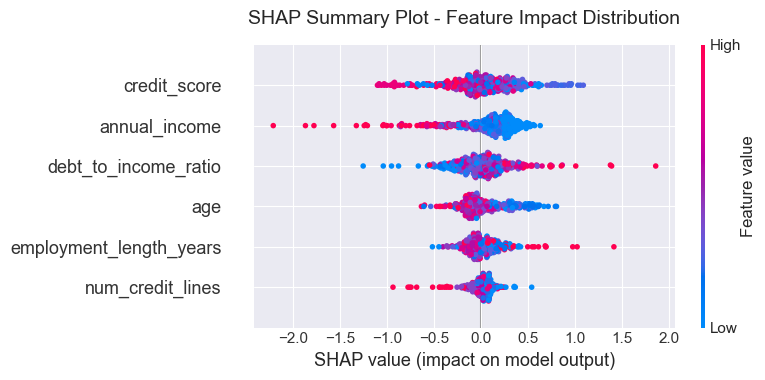

🔍 KEY INSIGHTS FROM SUMMARY PLOT
1. Most important features are at the top
2. Color shows feature value: RED (high) vs BLUE (low)
3. Position shows SHAP value: RIGHT (increases default risk)
                              LEFT (decreases default risk)

Expected pattern:
  • High debt_to_income (red) → Right (increases default)
  • High credit_score (red) → Left (decreases default)


In [10]:
# Create SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
plt.title("SHAP Summary Plot - Feature Impact Distribution", fontsize=14, pad=15)
plt.tight_layout()
plt.show()

print("="*60)
print("🔍 KEY INSIGHTS FROM SUMMARY PLOT")
print("="*60)
print("1. Most important features are at the top")
print("2. Color shows feature value: RED (high) vs BLUE (low)")
print("3. Position shows SHAP value: RIGHT (increases default risk)")
print("                              LEFT (decreases default risk)")
print("\nExpected pattern:")
print("  • High debt_to_income (red) → Right (increases default)")
print("  • High credit_score (red) → Left (decreases default)")